In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

In [2]:
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

remaining_features = list(X.columns)
selected_features = []

rss_list = []
adj_r2_list = []
aic_list = []
bic_list = []
cv_error_list = []

n = len(y)

In [3]:
for k in range(len(X.columns)):

    best_rss = np.inf
    best_feature = None
    best_model = None

    for feature in remaining_features:

        current_features = selected_features + [feature]

        model = LinearRegression()
        model.fit(X[current_features], y)

        predictions = model.predict(X[current_features])

        rss = np.sum((y - predictions) ** 2)

        if rss < best_rss:
            best_rss = rss
            best_feature = feature
            best_model = model

    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    predictions = best_model.predict(X[selected_features])

    rss = np.sum((y - predictions) ** 2)

    p = len(selected_features)

    r2 = best_model.score(X[selected_features], y)

    adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

    mse = rss/n

    aic = n*np.log(mse) + 2*p
    bic = n*np.log(mse) + p*np.log(n)

    cv_scores = cross_val_score(
        LinearRegression(),
        X[selected_features],
        y,
        cv=5,
        scoring='neg_mean_squared_error'
    )

    cv_error = -cv_scores.mean()

    rss_list.append(rss)
    adj_r2_list.append(adj_r2)
    aic_list.append(aic)
    bic_list.append(bic)
    cv_error_list.append(cv_error)

    print(f"Step {p}: Added {best_feature}")


Step 1: Added MedInc
Step 2: Added HouseAge
Step 3: Added Latitude
Step 4: Added Longitude
Step 5: Added AveBedrms
Step 6: Added AveRooms
Step 7: Added AveOccup
Step 8: Added Population


In [4]:
print("\nOrder of Selected Features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")


Order of Selected Features:
1. MedInc
2. HouseAge
3. Latitude
4. Longitude
5. AveBedrms
6. AveRooms
7. AveOccup
8. Population


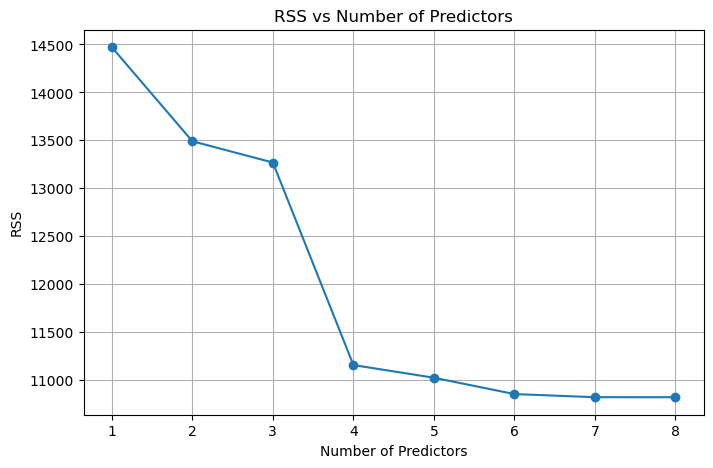

In [5]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(rss_list)+1), rss_list, marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("RSS")
plt.title("RSS vs Number of Predictors")
plt.grid(True)
plt.show()

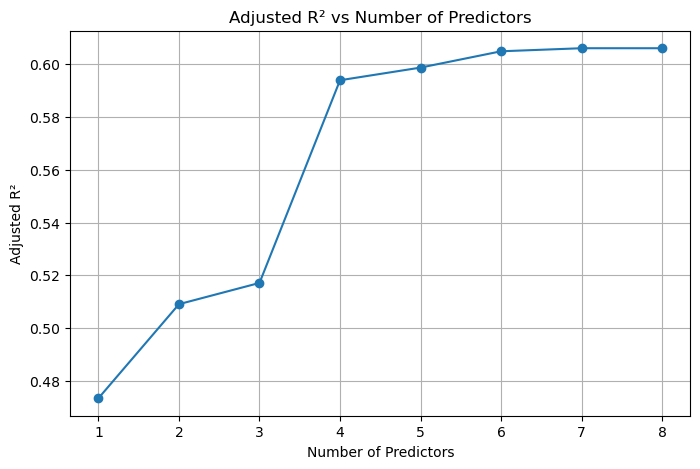

In [6]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(adj_r2_list)+1), adj_r2_list, marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R² vs Number of Predictors")
plt.grid(True)
plt.show()

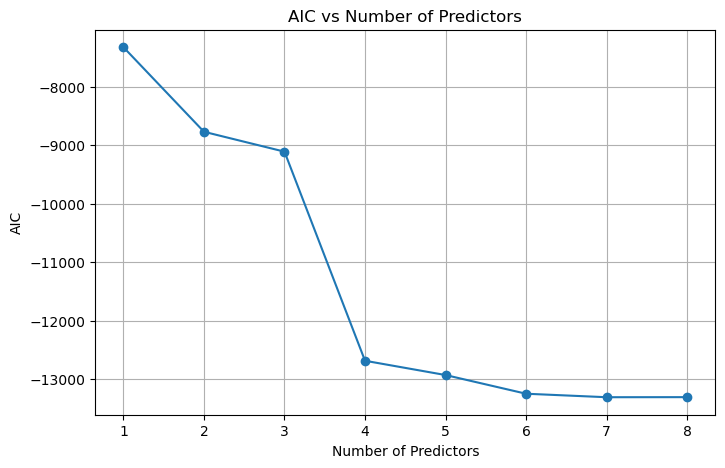

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(aic_list)+1), aic_list, marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("AIC")
plt.title("AIC vs Number of Predictors")
plt.grid(True)
plt.show()

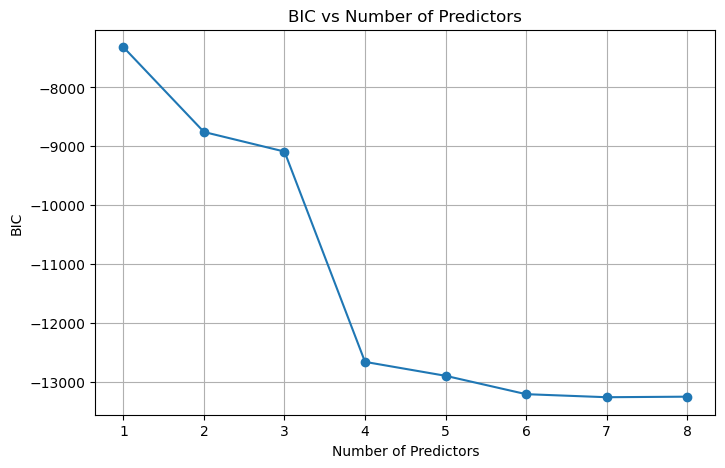

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(bic_list)+1), bic_list, marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("BIC")
plt.title("BIC vs Number of Predictors")
plt.grid(True)
plt.show()

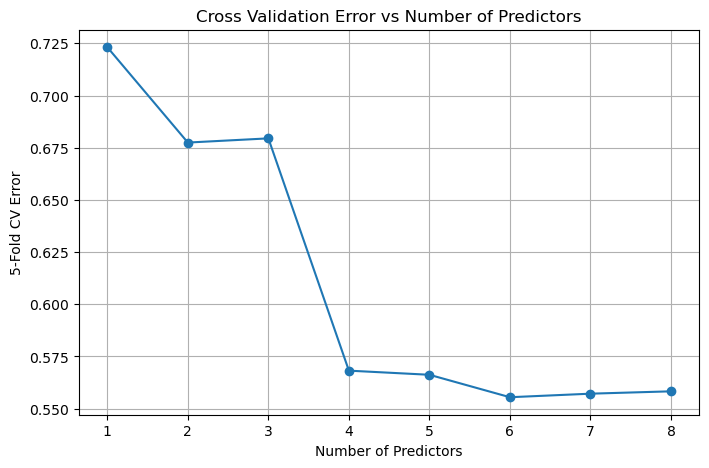

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cv_error_list)+1), cv_error_list, marker='o')
plt.xlabel("Number of Predictors")
plt.ylabel("5-Fold CV Error")
plt.title("Cross Validation Error vs Number of Predictors")
plt.grid(True)
plt.show()